/Users/audreychristabelleh/Downloads/machine learning/project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Model final (SGB) berhasil dilatih.

--- HASIL SGB (Gradient Boosting) ---
R²: 0.8731
RMSE: $4,437.75
MAE: $2,079.38

--- TABEL PERBANDINGAN (Actual vs Predicted) ---
    Actual Charges  Predicted Charges        Error
0       9095.06825       10352.634976  1257.566726
1       5272.17580        5578.240843   306.065043
2      29330.98315       29279.594816   -51.388334
3       9301.89355        9392.191235    90.297685
4      33750.29180       28767.056637 -4983.235163
5       4536.25900        5843.362771  1307.103771
6       2117.33885        2088.480858   -28.857992
7      14210.53595       15998.181519  1787.645569
8       3732.62510        4065.286591   332.661491
9      10264.44210       10082.131275  -182.310825
10     18259.21600       17478.126006  -781.089994
11      7256.72310        8836.338640  1579.615540
12      3947.41310        4126.354530   178.941430
13     46151.12450       44117.947467 -2033.177033
14     48673.55880       46523.246383 -2150.312417
15     44202.653

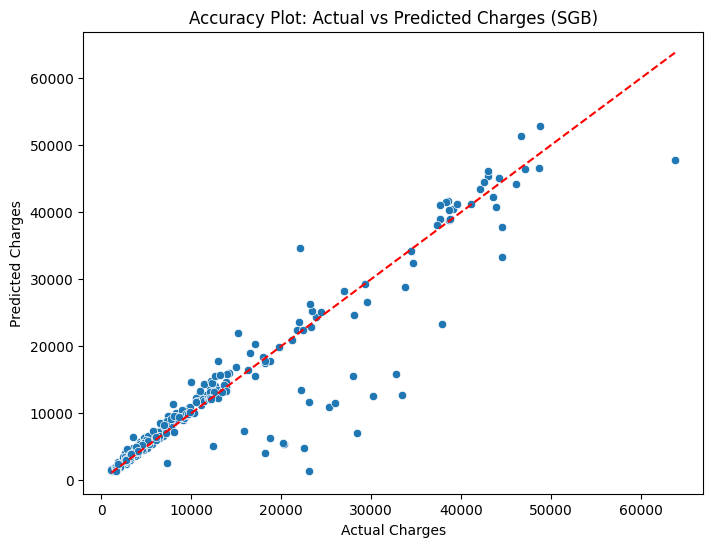

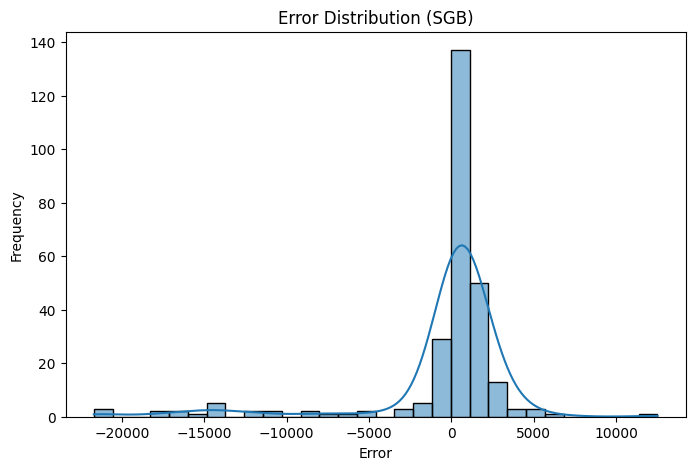

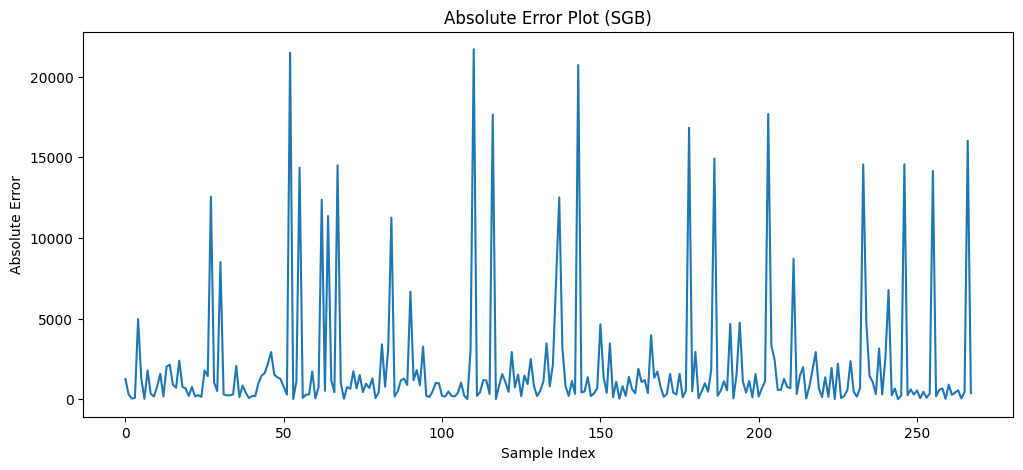


--- Feature Importance (SGB) ---
            Feature  Importance
4            smoker   47.675519
0               age   39.123520
2               bmi    7.602112
3          children    4.220315
1               sex    0.516449
7  region_southwest    0.394717
6  region_southeast    0.262089
5  region_northwest    0.205278


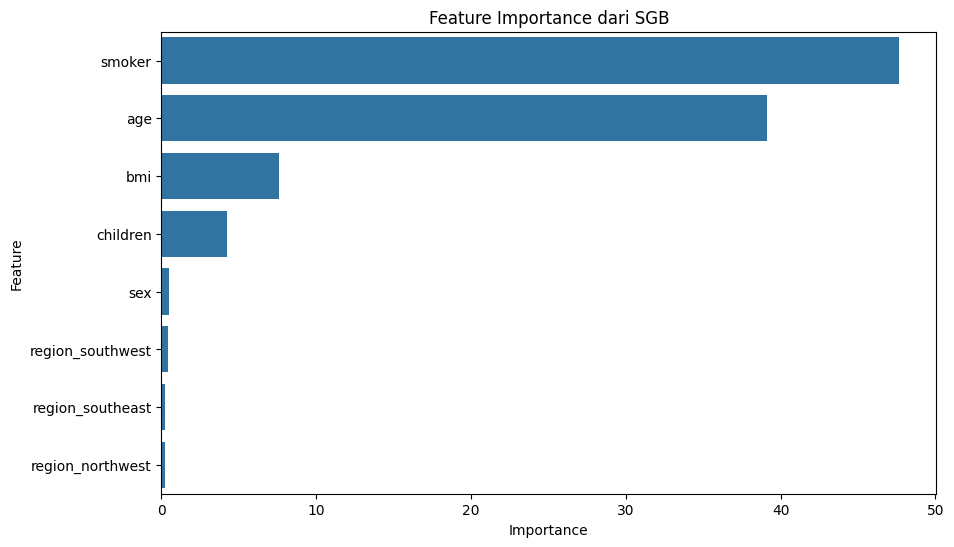


Menghitung SHAP values...


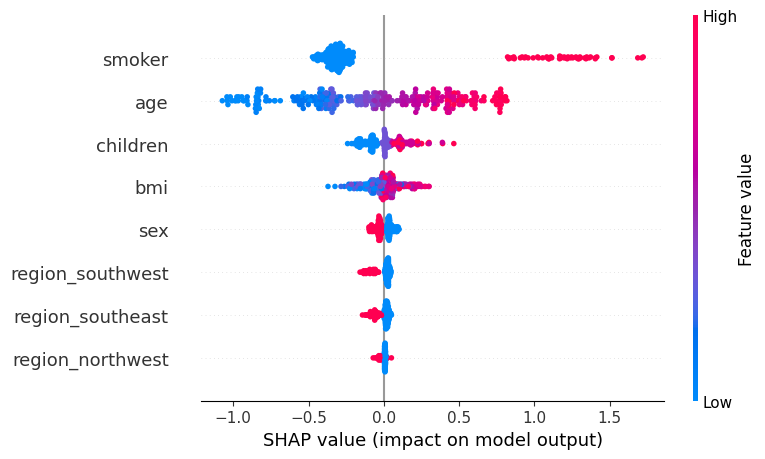

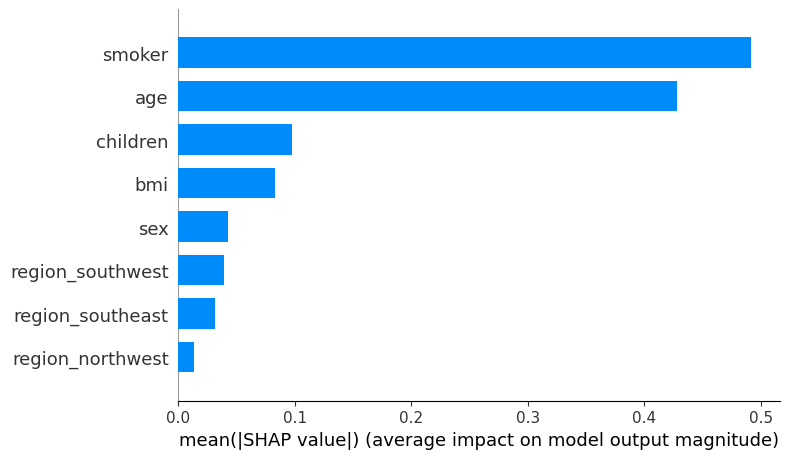


=== Rata-rata Kontribusi SHAP per Fitur ===
            Feature  Mean |SHAP Value|
4            smoker           0.492053
0               age           0.428345
3          children           0.097547
2               bmi           0.082926
1               sex           0.042350
7  region_southwest           0.039468
6  region_southeast           0.031828
5  region_northwest           0.013047

=== Penjelasan SHAP untuk 1 sampel (index 0) ===
            Feature Feature Value  SHAP Contribution
0               age            45           0.206152
3          children             2           0.099139
1               sex             0           0.035621
7  region_southwest         False           0.028911
6  region_southeast         False           0.017072
5  region_northwest         False           0.009660
2               bmi        25.175          -0.024187
4            smoker             0          -0.239154

=== Penjelasan Global Model Berdasarkan SHAP ===
- smoker memberikan kontrib

<Figure size 600x600 with 0 Axes>

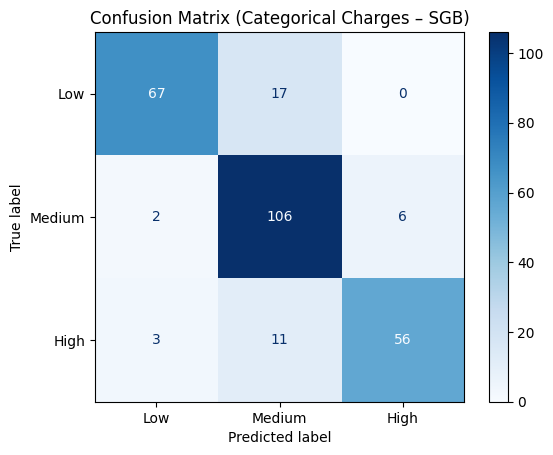

R2 (menggunakan rekonstruksi SHAP): 0.8731476744278013


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/audreychristabelleh/Downloads/machine learning/project/fullinsurance.csv', sep=';')

df['sex'] = df['sex'].apply(lambda x: 1 if x == 'male' else 0)
df['smoker'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

df['charges'] = np.log1p(df['charges'])

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_final = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,       
    random_state=42
)

model_final.fit(X_train, y_train)

print("\nModel final (SGB) berhasil dilatih.")

y_pred_log = model_final.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

r2_final = r2_score(y_test_actual, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae_final = mean_absolute_error(y_test_actual, y_pred)

print("\n--- HASIL SGB (Gradient Boosting) ---")
print(f"R²: {r2_final:.4f}")
print(f"RMSE: ${rmse_final:,.2f}")
print(f"MAE: ${mae_final:,.2f}")


comparison_df = pd.DataFrame({
    "Actual Charges": y_test_actual.values,
    "Predicted Charges": y_pred,
})
comparison_df["Error"] = comparison_df["Predicted Charges"] - comparison_df["Actual Charges"]

print("\n--- TABEL PERBANDINGAN (Actual vs Predicted) ---")
print(comparison_df.head(20))

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_actual, y=y_pred)
sns.lineplot(x=y_test_actual, y=y_test_actual, color='red', linestyle='--')
plt.title("Accuracy Plot: Actual vs Predicted Charges (SGB)")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(comparison_df["Error"], bins=30, kde=True)
plt.title("Error Distribution (SGB)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

comparison_df["Absolute Error"] = comparison_df["Error"].abs()

plt.figure(figsize=(12,5))
plt.plot(comparison_df["Absolute Error"].values)
plt.title("Absolute Error Plot (SGB)")
plt.xlabel("Sample Index")
plt.ylabel("Absolute Error")
plt.show()

importances = model_final.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances * 100
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance (SGB) ---")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance dari SGB')
plt.show()

print("\nMenghitung SHAP values...")

shap.initjs()
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

shap_abs_mean = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP Value|": shap_abs_mean
}).sort_values(by="Mean |SHAP Value|", ascending=False)

print("\n=== Rata-rata Kontribusi SHAP per Fitur ===")
print(shap_importance_df)

index_sample = 0
sample = X_test.iloc[index_sample]

print(f"\n=== Penjelasan SHAP untuk 1 sampel (index {index_sample}) ===")
contrib_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": sample.values,
    "SHAP Contribution": shap_values[index_sample]
}).sort_values(by="SHAP Contribution", ascending=False)

print(contrib_df)

shap.force_plot(explainer.expected_value, shap_values[index_sample], sample)

print("\n=== Penjelasan Global Model Berdasarkan SHAP ===")
for i, row in shap_importance_df.iterrows():
    print(f"- {row['Feature']} memberikan kontribusi rata-rata {row['Mean |SHAP Value|']:.4f}")

print("\n=== Penjelasan untuk Sampel Tunggal ===")
top_pos = contrib_df.head(3)
top_neg = contrib_df.tail(3)

print("\nFitur yang PALING meningkatkan prediksi biaya:")
for _, r in top_pos.iterrows():
    print(f"- {r['Feature']} (nilai {r['Feature Value']}) menaikkan prediksi sebesar {r['SHAP Contribution']:.4f}")

print("\nFitur yang PALING MENURUNKAN prediksi biaya:")
for _, r in top_neg.iterrows():
    print(f"- {r['Feature']} (nilai {r['Feature Value']}) menurunkan prediksi sebesar {r['SHAP Contribution']:.4f}")

comparison_df["Error"] = comparison_df["Predicted Charges"] - comparison_df["Actual Charges"]
comparison_df["AbsError"] = comparison_df["Error"].abs()

bins = [0, 1000, 3000, np.inf]
labels = ["Accurate (<1k)", "Moderate (1k–3k)", "Large (>3k)"]

comparison_df["Error Category"] = pd.cut(comparison_df["AbsError"], bins=bins, labels=labels)

conf_matrix_reg = comparison_df["Error Category"].value_counts().to_frame("Count")

print("\n=== Pseudo Confusion Matrix for Regression ===")
print(conf_matrix_reg)

bins = [0, 5000, 15000, 30000, np.inf]
labels = ['Low', 'Medium', 'High', 'Very High']

comparison_df["ActualBin"] = pd.cut(comparison_df["Actual Charges"], bins=bins, labels=labels)
comparison_df["PredBin"] = pd.cut(comparison_df["Predicted Charges"], bins=bins, labels=labels)

cm_reg = pd.crosstab(comparison_df["ActualBin"], comparison_df["PredBin"], 
                     rownames=["Actual"], colnames=["Predicted"])

print("\n=== Regression Confusion Matrix (Binned) ===")
print(cm_reg)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

bins = [0, 5000, 15000, np.inf]
labels = ['Low', 'Medium', 'High']

y_test_cat = pd.cut(y_test_actual, bins=bins, labels=labels)
y_pred_cat = pd.cut(y_pred, bins=bins, labels=labels)

cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Categorical Charges – SGB)")
plt.show()

shap_pred = explainer.expected_value + shap_values.sum(axis=1)
shap_pred = np.expm1(shap_pred)         

r2_shap = r2_score(y_test_actual, shap_pred)

print("R2 (menggunakan rekonstruksi SHAP):", r2_shap)
